<a href="https://colab.research.google.com/github/plnu-biomechanics/kin4042/blob/main/notebooks/kin4042_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://www.pointloma.edu/sites/default/files/styles/basic_page/public/images/PLNU_Biomechanics_Lab_green_yellowSD_HiRes.png" width=400>

## **KIN 4042 Sports Informatics**
Instructor: Arnel Aguinaldo, PhD

**Lab 2: Estimating jump performance reliability**

In this lab, you will summarize and analyze data metrics that were previously collected from 23 basketball players with CMJ performance testing in a study by Perez-Castilla et al. ([2021](https://doi.org/10.1371/journal.pone.0255458)). The dataset can be downloaded or ingested directly from our lab's GitHub repository.

*   `pone_0255458_s001.csv` from the PLNU Biomechanics Lab


**Cited Study:**

Pérez-Castilla, A., García-Ramos, A., Janicijevic, D., Delgado-García, G., De la Cruz, J. C., Rojas, F. J., & Cepero, M. (2021). Between-session reliability of performance and asymmetry variables obtained during unilateral and bilateral countermovement jumps in basketball players. *PloS One, 16*(7), e0255458. https://doi.org/10.1371/journal.pone.0255458

To further process the data for this lab, follow the steps in this **Colab notebook**, which contains instructions and sample code on how to wrangle and analyze the data.


### Create your own Colab Notebook

1. Go to **File -> New notebook in Drive** to open a new notebook in your Python environment:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/file_notebook.png" width=450>

2. Rename your Colab notebook using this naming format: **lastname_kin4042_lab#.ipynb** (e.g., "aguinaldo_kin4042_lab1.ipynb")
3. Click on the **+ Code** option above to insert a new code cell: <br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/addcode.png" width=280>

4. The data you will parse and analyze for this lab will be temporarily stored in your Colab's runtime directory, which can be accessed by clicking on the folder icon in the left menu:<br>
<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin6015/main/notebooks/images/colab_folder.png" width=400>

5. Copy the following lines of code to import the packages needed for this analysis and to load the data files into your working directory. **Note**: These files are "runtime" access only, meaning they are only temporarily stored in your working directory and show up when your notebook is in session.


## 🔄 Data Ingestion

This is a simple method of ingesting data into your working directory that involves minimal coding. First let's create a lab folder in your working directory using just these 3 lines of code:


In [1]:
# CREATE LAB FOLDER IN YOUR WORKING DIRECTORY

# import the os library to your working environment, allowing access to the
# libraries and functions required to read and write to your working environment
import os

# create a data_dir variable with a string value of your directory
data_dir = "kin4042/lab2"
os.makedirs(data_dir, exist_ok=True)

print("Created lab directory.")


Created lab directory.


Your working directory should now look something like this:

<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin4042/main/notebooks/images/kin4042_create-lab-directory.png" width=400>

Next, import the dataset (*.csv file) from GitHub to your working directory.


In [2]:
# Import the URL library to access publicly available data on the web
import urllib.request

# This is the raw URL for the high performance data file (*.csv) on GitHub
url = (
    "https://raw.githubusercontent.com/plnu-biomechanics/"
    "kin4042/refs/heads/main/labs/pone_0255458_s001.csv"
)

# Define data_path of the file on your working directory
data_filename = "pone_0255458_s001.csv"
data_path = os.path.join(data_dir, data_filename)

# --------------------------------------------------
# Download file directly from GitHub
# --------------------------------------------------
urllib.request.urlretrieve(url, data_path)

print("Existing files in the lab directory:")
print(os.listdir(data_dir))

Existing files in the lab directory:
['pone_0255458_s001.csv']


## 🔄 Data Frames

<img src="https://raw.githubusercontent.com/plnu-biomechanics/kin4042/main/notebooks/images/pandas_logo.jpg" width=400>

Before the data can be analyzed, they need to be parsed into `DataFrames` as described in previous labs.

In this lab, we will use the powerful `pandas` library to create a data frame from the `pone_0255458_s001.csv` file.

You can use your favorite GenAI agent to help you with populating these two data frames.

### ✋ GenAI prompt:
Generate code that will load a data frame with data from the `pone_0255458_s001.csv` file as well as inspect and print out the column name for each variable for analysis. Count the number of unique players and session per player included in the data frame.

*Note: Be sure to state in a comment the GenAI agent you used to generate the code similar to this comment:*

```
# =======================================
#  Code generated or assisted by Claude
# =======================================
```



In [5]:
# =======================================
#  Code generated or assisted by Gemini
# =======================================

import pandas as pd

# Load the dataset into a pandas DataFrame
plosone_df = pd.read_csv(data_path)

# Inspect and print out the column names for analysis
print("Column Information:")
plosone_df.info()

# Count the number of unique players
num_unique_players = plosone_df['Code'].nunique()
print(f"\nNumber of unique players: {num_unique_players}")

# Count the number of unique sessions per player
sessions_per_player = plosone_df.groupby('Code')['Session'].nunique()
print("\nNumber of unique sessions per player:")
print(sessions_per_player)

display(plosone_df.head())

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46 entries, 0 to 45
Data columns (total 32 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Code             46 non-null     int64  
 1   Session          46 non-null     int64  
 2   MF_UNICMJ_RIGHT  46 non-null     float64
 3   PF_UNICMJ_RIGHT  46 non-null     float64
 4   MV_UNICMJ_RIGHT  46 non-null     float64
 5   PV_UNICMJ_RIGHT  46 non-null     float64
 6   MP_UNICMJ_RIGHT  46 non-null     float64
 7   PP_UNICMJ_RIGHT  46 non-null     float64
 8   CI-UNICMJ_RIGHT  46 non-null     float64
 9   JH_UNICMJ_RIGHT  46 non-null     float64
 10  MF_UNICMJ_LEFT   46 non-null     float64
 11  PF_UNICMJ_LEFT   46 non-null     float64
 12  MV_UNICMJ_LEFT   46 non-null     float64
 13  PV_UNICMJ_LEFT   46 non-null     float64
 14  MP_UNICMJ_LEFT   46 non-null     float64
 15  PP_UNICMJ_LEFT   46 non-null     float64
 16  CI-UNICMJ_LEFT   46 non-null     float64
 17

,Code,Session,MF_UNICMJ_RIGHT,PF_UNICMJ_RIGHT,MV_UNICMJ_RIGHT,PV_UNICMJ_RIGHT,MP_UNICMJ_RIGHT,PP_UNICMJ_RIGHT,CI-UNICMJ_RIGHT,JH_UNICMJ_RIGHT,...,MP_BICMJ_RIGHT,PP_BICMJ_RIGHT,CI-BICMJ_RIGHT,MF_BICMJ_LEFT,PF_BICMJ_LEFT,MV_BICMJ_LEFT,PV_BICMJ_LEFT,MP_BICMJ_LEFT,PP_BICMJ_LEFT,CI-BICMJ_LEFT
0,1,1,1126.2,1379.4,1.22,2.10,1254.2,2396.2,134.1,0.19,...,952.2,1891.2,94.2,616.7,756.4,1.06,1.87,600.4,1245.0,65.8
1,2,1,1127.5,1308.5,1.20,2.06,1242.9,2329.0,138.4,0.15,...,1329.6,2194.8,109.4,676.6,831.9,1.65,2.89,1027.4,1862.0,102.0
2,3,1,1034.0,1265.5,1.29,2.15,1224.2,2036.3,130.6,0.25,...,1117.0,1843.5,102.1,643.1,773.7,1.40,2.67,813.2,1621.6,92.1
3,4,1,1052.0,1318.1,1.26,2.28,1236.9,2389.7,135.1,0.21,...,1121.4,2050.8,95.6,700.4,811.9,1.44,2.44,908.0,1616.2,83.6
4,5,1,1293.6,1502.1,1.23,2.13,1466.5,2630.0,155.4,0.20,...,1765.4,3193.5,140.9,798.5,962.1,0.90,1.54,656.5,1179.5,64.7


## 📓Lab Note

Take note of the number of players with CMJ data in the data frame and the number of sessions per player.

## 📈 Inspection

In this lab, the between-session reliability of the single-leg CMJ metrics will be measured and assessed. These metrics include:

*   `MF` = mean force
*   `PF` = peak force
*   `MV` = mean velocity
*   `PV` = peak velocity
*   `MP` = mean power
*   `PP` = peak power
*   `CI` = concentric impulse
*   `JH` = jump height

These are denoted in each column heading as a prefix followed by the hp test (`UNICMJ`) and side (`RIGHT`, `LEFT`). For example,

`PV_UNICMJ_RIGHT` = peak velocity during a single-leg CMJ on the right leg

While we're analyzing pre-inspected data, it's always a good idea to confirm the quality of the variables of interest by checking for missing values and outliers.


## 🧹 Data Quality Check: Missing Values

It's important to check for missing values in a dataset as they can impact analysis and modeling. We'll count the number of `NaN` values for each column in `plosone_df`.

###✋ GenAI prompt ###
Count the number of `NaN` or missing values in `plosone_df`.

In [6]:
# =======================================
#  Code generated or assisted by Gemini
# =======================================

# Check for missing values in plosone_df
missing_values_plosone = plosone_df.isnull().sum()
print("Missing values in plosone_df:")
print(missing_values_plosone[missing_values_plosone > 0])

Missing values in plosone_df:
Series([], dtype: int64)


## 📈 Normality

Another inspection check is to examine the distribution of each metric and determine whether it is normal or not. We will use the Shapiro-Wilk test to determine normality.

### ✋ GenAI prompt ###
Determine the normality of each metric in `plosone_df` using the Shapiro-Wilk test.

In [15]:
# =======================================
#  Code generated or assisted by Gemini
# =======================================
import pandas as pd
from scipy import stats

# Identify numerical columns for normality testing, excluding 'Code' and 'Session'
metric_columns = plosone_df.columns.drop(['Code', 'Session']).tolist()

print("Shapiro-Wilk Test for Normality:")
print("--------------------------------")

# Perform Shapiro-Wilk test for each metric column
for col in metric_columns:
    # The Shapiro-Wilk test is sensitive to small sample sizes and can return NaNs for constant data.
    # We'll filter out NaNs and check for sufficient variance.
    data = plosone_df[col].dropna()

    if len(data) < 3: # Shapiro-Wilk test requires at least 3 data points
        print(f"Skipping '{col}': Not enough data points ({len(data)}).")
        continue

    if data.std() == 0: # Check for zero variance
        print(f"Skipping '{col}': Data has zero variance (constant values).")
        continue

    stat, p = stats.shapiro(data)
    print(f"Metric: {col}")
    print(f"  W-statistic = {stat:.3f}, p-value = {p:.3f}")
    if p < 0.05:
        print("  -> Data is NOT normally distributed (reject H0)")
    else:
        print("  -> Data IS normally distributed (fail to reject H0)")
    print("\n")

Shapiro-Wilk Test for Normality:
--------------------------------
Metric: MF_UNICMJ_RIGHT
  W-statistic = 0.981, p-value = 0.666
  -> Data IS normally distributed (fail to reject H0)


Metric: PF_UNICMJ_RIGHT
  W-statistic = 0.974, p-value = 0.402
  -> Data IS normally distributed (fail to reject H0)


Metric: MV_UNICMJ_RIGHT
  W-statistic = 0.947, p-value = 0.036
  -> Data is NOT normally distributed (reject H0)


Metric: PV_UNICMJ_RIGHT
  W-statistic = 0.965, p-value = 0.177
  -> Data IS normally distributed (fail to reject H0)


Metric: MP_UNICMJ_RIGHT
  W-statistic = 0.956, p-value = 0.077
  -> Data IS normally distributed (fail to reject H0)


Metric: PP_UNICMJ_RIGHT
  W-statistic = 0.959, p-value = 0.100
  -> Data IS normally distributed (fail to reject H0)


Metric: CI-UNICMJ_RIGHT
  W-statistic = 0.978, p-value = 0.522
  -> Data IS normally distributed (fail to reject H0)


Metric: JH_UNICMJ_RIGHT
  W-statistic = 0.970, p-value = 0.273
  -> Data IS normally distributed (fail to

## 📓Lab Note

Take note of the CMJ metrics that were determined to be normal and those that were not in `plosone_df`.

## 📊 Data Visualization: Summary Statistics

Let's visualize the descriptive statistics for all metrics by `session` from `plosone_df` using box plots. This can help us see how each metric differs across sessions.

###✋ GenAI prompt ###
Generate box plots for each metric in `plosone_df` stratified by `session` with the order explicity set from `1` through `2`.

/tmp/ipykernel_13279/332859869.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Session', y=col, data=plosone_df, order=[1, 2], palette='viridis')
/tmp/ipykernel_13279/332859869.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Session', y=col, data=plosone_df, order=[1, 2], palette='viridis')
/tmp/ipykernel_13279/332859869.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Session', y=col, data=plosone_df, order=[1, 2], palette='viridis')
/tmp/ipykernel_13279/332859869.py:17: FutureWarning: 

Passing `palette` without assi

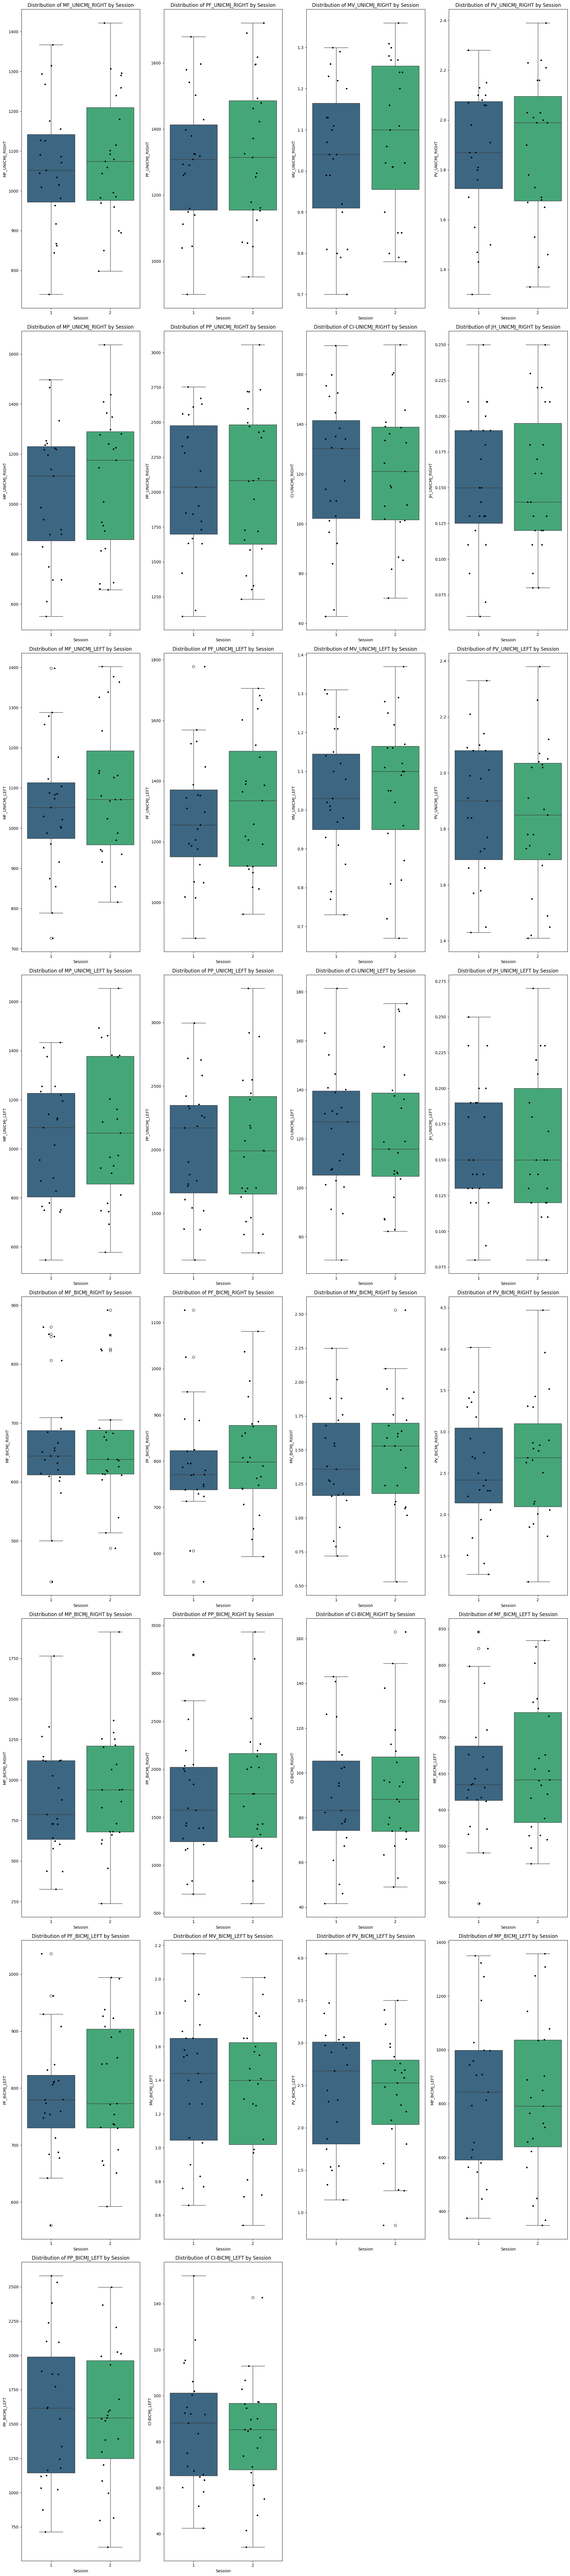

In [11]:
# =======================================
#  Code generated or assisted by Gemini
# =======================================

import matplotlib.pyplot as plt
import seaborn as sns

# Get the list of metric columns (excluding 'Code' and 'Session')
metric_cols = plosone_df.columns.drop(['Code', 'Session']).tolist()

# Set the figure size to accommodate multiple plots
plt.figure(figsize=(20, len(metric_cols) * 3))

# Create a box plot for each metric, stratified by session
for i, col in enumerate(metric_cols):
    plt.subplot(len(metric_cols) // 4 + 1, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='Session', y=col, data=plosone_df, order=[1, 2], palette='viridis')
    # Add individual player values as points
    sns.stripplot(x='Session', y=col, data=plosone_df, order=[1, 2], color='black', jitter=0.2, size=4)
    plt.title(f'Distribution of {col} by Session')
    plt.xlabel('Session')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## 📓Lab Note

Copy the box plots and paste it onto your lab write-up.

## 📊 Data Calculation: Limb Asymmetry

Let's calculate the inter-limb symmetry in the single-leg metrics using the equation described by Castilla et al (2021):

**% difference = 100 / (max value) * (min value) * -1 + 100**



###✋ GenAI prompt ###
Calculate the inter-limb symmetry in the `UNICMJ` metrics using the equation,
% difference = 100 / (max value) * (min value) * -1 + 100, and add them to `plosone_df`.

In [ ]:
# **********************************
# ENTER YOUR AI-ASSISTED CODE BELOW
# **********************************


## 📓Lab Note

Copy the scatter plot and paste it onto your lab write-up.

## 📊 Reliabilty Analysis

Next, we will examine the between-session reliability of each CMJ metric using the following statistics:

*   paired t-test (*p* value)
*   effect size (ES) using Cohen's *d*
*   coefficient of variation (CV) using SEM/mean * 100
*   intraclass correlation coefficient (ICC) using ICC[3,1] model


###✋ GenAI prompt ###
For each metric, compute and list the paired t-test p-value, Cohen's d effect size (ES), coefficient of variation (%CV), and ICC[3,1] reliability.

In [20]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.0 MB/s eta 0:00:00


In [23]:
# =======================================
#  Code generated or assisted by Gemini
# =======================================

import pandas as pd
from scipy import stats
import numpy as np
import pingouin as pg

# Ensure pingouin is installed (uncomment and run if you encounter ModuleNotFoundError)
# %pip install pingouin

# Identify numerical columns for reliability testing, excluding 'Code' and 'Session'
metric_columns = plosone_df.columns.drop(['Code', 'Session']).tolist()

reliability_results = {}

print("Reliability Analysis Results:")
print("----------------------------")

for col in metric_columns:
    # Prepare data for paired comparisons
    # Pivot the DataFrame to have 'Code' as index and 'Session' as columns for the current metric
    df_metric = plosone_df[['Code', 'Session', col]].pivot(index='Code', columns='Session', values=col)
    df_metric.columns = ['Session_1', 'Session_2'] # Rename columns for clarity

    # Drop rows where either session has NaN for this metric, ensuring paired samples
    df_metric_cleaned = df_metric.dropna()

    if len(df_metric_cleaned) < 2: # Need at least 2 complete paired data points for paired t-test and ICC
        reliability_results[col] = {
            "Paired t-test p-value": np.nan,
            "Cohen's d": np.nan,
            "%CV": np.nan,
            "ICC[3,1]": np.nan,
            "Note": "Not enough complete paired data points for analysis."
        }
        print(f"Skipping '{col}': Not enough complete paired data points for analysis.\n")
        continue

    session1_data = df_metric_cleaned['Session_1']
    session2_data = df_metric_cleaned['Session_2']

    # 1. Paired t-test p-value
    ttest_result = stats.ttest_rel(session1_data, session2_data, nan_policy='omit')
    p_value = ttest_result.pvalue

    # 2. Cohen's d effect size (ES) for paired samples
    # Cohen's d for paired samples = mean_difference / std_dev_of_differences
    differences = session1_data - session2_data
    mean_diff = np.mean(differences)
    std_diff = np.std(differences, ddof=1) # ddof=1 for sample standard deviation

    if std_diff == 0:
        cohens_d = 0.0 # If no variability in differences, effect size is 0
    else:
        cohens_d = mean_diff / std_diff

    # 3. Intraclass Correlation Coefficient (ICC) using ICC[3,1] model
    # ICC[3,1] corresponds to a two-way mixed-effects model for absolute agreement on single measures.
    # In pingouin, this is achieved with model='mixed' and type='agreement', and selecting 'ICC3'.
    icc_calc_df = plosone_df[['Code', 'Session', col]].copy()
    icc_calc_df.rename(columns={'Code': 'Subject', 'Session': 'Rater', col: 'Measurements'}, inplace=True)

    icc_result = pg.icc(
        data=icc_calc_df.dropna(), # Drop NaNs for ICC calculation, ensuring complete cases for ICC
        dv='Measurements',
        wid='Subject',
        within='Rater',
        model='mixed',
        type='agreement'
    )
    # The 'ICC3' row is for single measures (k=1) in a two-way mixed model for absolute agreement
    icc_value = icc_result[icc_result['Type'] == 'ICC3']['ICC'].iloc[0]

    # 4. Coefficient of Variation (%CV) using SEM/mean * 100
    # SEM (Standard Error of Measurement) = Pooled SD * sqrt(1 - ICC)
    # Pooled Standard Deviation (SD_pooled) is the square root of the average variance of the two sessions
    var_s1 = np.var(session1_data, ddof=1)
    var_s2 = np.var(session2_data, ddof=1)
    pooled_sd = np.sqrt((var_s1 + var_s2) / 2)

    # Grand Mean of both sessions
    grand_mean = (session1_data.mean() + session2_data.mean()) / 2

    # Standard Error of Measurement (SEM_m)
    # Cap ICC at 1 for SEM calculation to prevent issues if ICC is slightly > 1 due to floating point arithmetic
    sem_m_calc_icc = min(icc_value, 1.0)
    if sem_m_calc_icc < 0: # If ICC is negative, it often implies no reliability, so use 0 for calculation
        sem_m = pooled_sd * np.sqrt(1 - 0)
    else:
        sem_m = pooled_sd * np.sqrt(1 - sem_m_calc_icc)

    percent_cv = (sem_m / grand_mean) * 100 if grand_mean != 0 else np.nan

    reliability_results[col] = {
        "Paired t-test p-value": p_value,
        "Cohen's d": cohens_d,
        "%CV": percent_cv,
        "ICC[3,1]": icc_value
    }

# Print formatted results
for metric, res in reliability_results.items():
    print(f"Metric: {metric}")
    for key, value in res.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.3f}")
        else:
            print(f"  {key}: {value}")
    print("\n")

Reliability Analysis Results:
----------------------------


AttributeError: module 'pingouin' has no attribute 'icc'

## 📓Lab Note

Copy the scatter plot and paste it onto your lab write-up.

## 📔 Final Notes ##

☝ Notice in these last couple of prompts, the actual names of the bat speed, grip strength, and IMTP force metrics were not used. By now, the AI agent knows the exact names of the variables of interest so there's no need to list them exactly in your prompts (but it helps!). Based on the plots and R^2 values, it looks IMTP force is more predictive of bat speed than grip strength!

💡 **What other high performance testing metrics can predict bat speed?**

Let's put your vibe code skills to the test and complete the lab by selecting two more potential bat speed predictors from either data frame using the same approach we did for grip strength and IMTP force. Use the above prompts and/or code to generate the scatter plots of your selected independent variables.




In [ ]:
# **********************************
# ENTER YOUR AI-ASSISTED CODE BELOW
# **********************************